In [1]:
from sae_analysis import (
    load_hooked_model,
    make_sae_config,
    train_sae,
    save_sae,
    load_sae,
    sae_eval,
    feature_alignment,
    layerwise_cka,
    plot_cka_profile,
    lora_weight_diffs,
    lora_diff_rank_structure,
    plot_weight_diff_heatmap,
    plot_singular_values,
    get_sae_activations,
    temporal_stats,
    plot_alignment_histogram,
    plot_temporal_comparison,
    plot_reconstruction_comparison,
)

In [2]:
MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
HOOK_NAME = "blocks.15.hook_resid_post"
D_IN = 2048
EXPANSION = 8
K = 64
TRAINING_TOKENS = 10_000_000
CONTEXT_SIZE = 256
DATASET = "Skylion007/openwebtext"
SAE_DIR = "/home/jay/repos/llm-jepa/trained_saes"

## Train SAEs

Train one SAE per model on the last layer residual stream. Same hyperparameters for both so differences are attributable to the model, not the SAE training.

In [3]:
from pathlib import Path

trained_saes = {}
for label, model_path in MODELS.items():
    sae_path = Path(SAE_DIR) / f"{label.lower()}_layer15"
    
    if sae_path.exists():
        print(f"Loading existing SAE for {label} from {sae_path}")
        trained_saes[label] = load_sae(sae_path, device="cuda")
    else:
        print(f"Training SAE for {label}...")
        sae = train_sae(
            model_path,
            hook_name=HOOK_NAME,
            d_in=D_IN,
            expansion_factor=EXPANSION,
            k=K,
            training_tokens=TRAINING_TOKENS,
            context_size=CONTEXT_SIZE,
            dataset_path=DATASET,
        )
        save_sae(sae, sae_path)
        trained_saes[label] = sae
        
print(f"SAEs loaded: {list(trained_saes.keys())}")

Loading existing SAE for NTP from /home/jay/repos/llm-jepa/trained_saes/ntp_layer15
Loading existing SAE for STP from /home/jay/repos/llm-jepa/trained_saes/stp_layer15
SAEs loaded: ['NTP', 'STP']


/home/jay/miniconda3/envs/jepa/lib/python3.14/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [4]:
## SAE Quality Check

from datasets import load_dataset

# Load diverse openwebtext for dead feature estimation (needs n_batches_dead * batch_size texts)
_ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
eval_texts = [ex["text"][:1024] for ex, _ in zip(_ds, range(256))]

eval_results = {}
for label, model_path in MODELS.items():
    print(f"{label}:")
    model = load_hooked_model(model_path, device="cuda")
    eval_results[label] = sae_eval(
        model, trained_saes[label], eval_texts,
        hook_name=HOOK_NAME, n_batches=4, n_batches_dead=32, batch_size=8, seq_len=128,
    )
    del model
    import torch; torch.cuda.empty_cache()

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

NTP:
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  explained_var=0.739  l0=27.0  dead=0.907 (over 32,768 tokens)  mse=0.097
STP:
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  explained_var=0.756  l0=25.5  dead=0.893 (over 32,768 tokens)  mse=0.096


explained variance: the percentage of the structure that the sae captures
l0 - the mean number of features that activate per token. We trained for k=64
dead: fraction of the features that never fired over the eval batch.

## Feature Alignment

For each feature in the NTP SAE, find its best match (max cosine similarity) in the STP SAE, and vice versa. High similarity = same feature exists in both models.

In [5]:
import numpy as np

In [6]:
alignment = feature_alignment(trained_saes["NTP"], trained_saes["STP"])

print(f"NTP→STP median max cosine sim: {np.median(alignment['a_to_b']):.3f}")
print(f"STP→NTP median max cosine sim: {np.median(alignment['b_to_a']):.3f}")
print(f"NTP→STP fraction > 0.9: {(alignment['a_to_b'] > 0.9).mean():.3f}")
print(f"STP→NTP fraction > 0.9: {(alignment['b_to_a'] > 0.9).mean():.3f}")

NTP→STP median max cosine sim: 0.207
STP→NTP median max cosine sim: 0.204
NTP→STP fraction > 0.9: 0.001
STP→NTP fraction > 0.9: 0.001


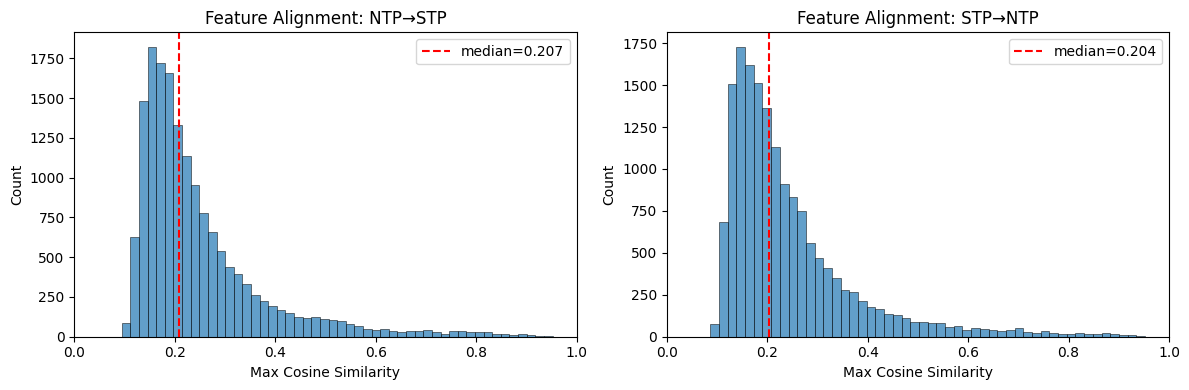

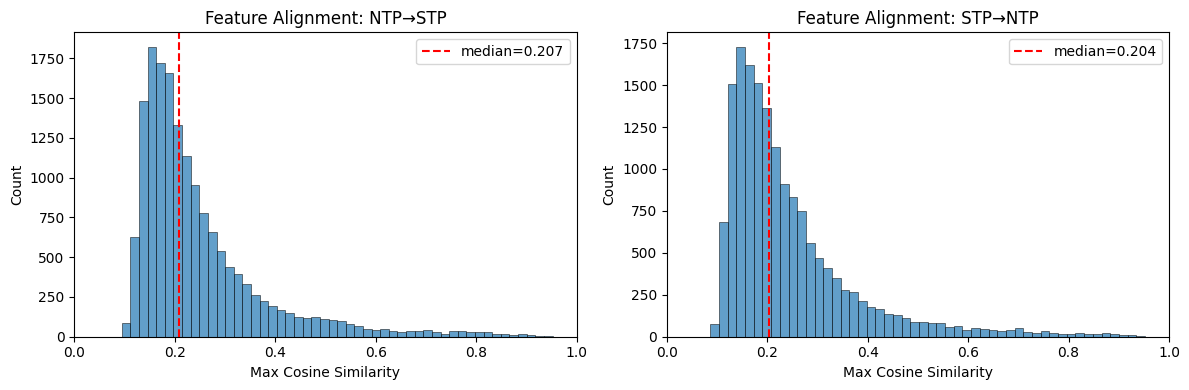

In [7]:
import numpy as np
plot_alignment_histogram(alignment)

interpretation: this isn't very useful, there is low similarity between two, but it's likely that it's just because the models found geometrically different representations.

## Temporal Activation Patterns

Run both models on shared sequences, encode with their respective SAEs, and compare how features behave across token positions.

In [8]:
import torch
from datasets import load_dataset

# Grab a batch of openwebtext sequences for temporal analysis
ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
texts = [ex["text"][:1024] for ex, _ in zip(ds, range(64))]

all_temporal_stats = {}
for label, model_path in MODELS.items():
    print(f"Computing temporal stats for {label}...")
    model = load_hooked_model(model_path, device="cuda")
    sae = trained_saes[label]
    
    # Tokenize
    tokens = model.to_tokens(texts, padding_side="right")[:, :CONTEXT_SIZE]
    
    # Get SAE activations in batches
    batch_size = 8
    all_acts = []
    for i in range(0, len(tokens), batch_size):
        batch = tokens[i : i + batch_size]
        acts = get_sae_activations(model, sae, batch, hook_name=HOOK_NAME)
        all_acts.append(acts.cpu())
    
    all_acts = torch.cat(all_acts, dim=0)
    all_temporal_stats[label] = temporal_stats(all_acts)
    
    del model
    torch.cuda.empty_cache()
    print(f"  autocorr mean: {all_temporal_stats[label]['autocorrelation'].mean():.4f}")
    print(f"  mean run length: {all_temporal_stats[label]['mean_run_length'][all_temporal_stats[label]['mean_run_length'] > 0].mean():.2f}")

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Computing temporal stats for NTP...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer


/home/jay/miniconda3/envs/jepa/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jay/miniconda3/envs/jepa/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  autocorr mean: 0.0076
  mean run length: 1.36
Computing temporal stats for STP...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  autocorr mean: 0.0084
  mean run length: 1.33


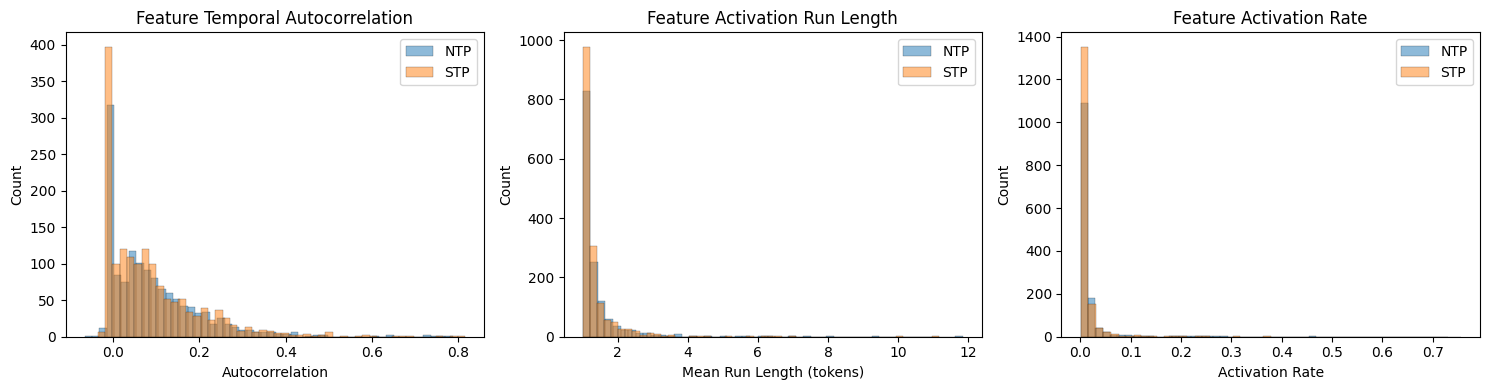

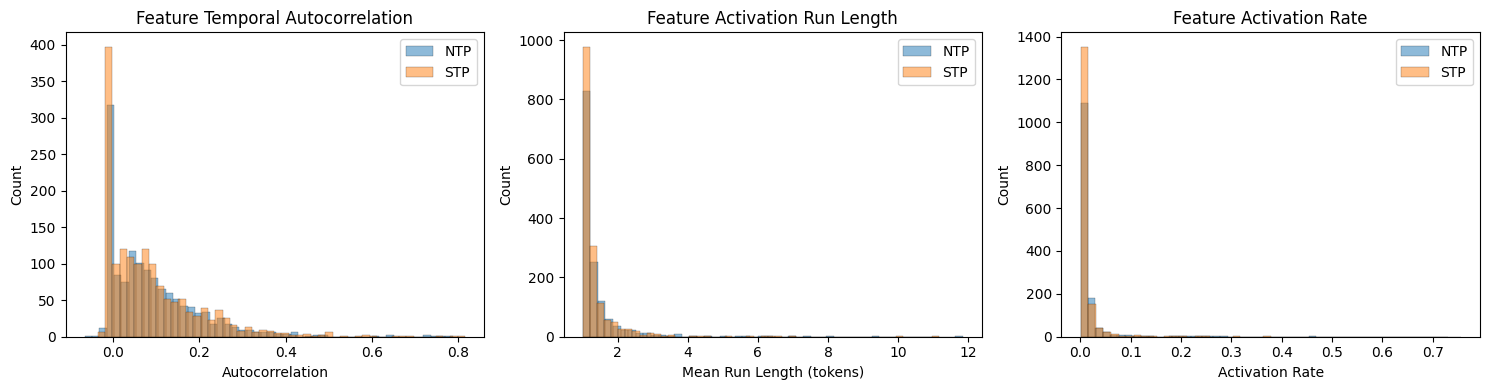

In [9]:
plot_temporal_comparison(all_temporal_stats["NTP"], all_temporal_stats["STP"])

## Centered Kernel Alignment

Compare representation geometry at every layer between NTP and STP, directly on residual stream activations. CKA is invariant to rotation and scaling — if STP just found a different coordinate system for the same information, CKA stays near 1. A drop indicates genuine geometric change.

Reference: Kornblith et al., NeurIPS 2019 (arxiv:1905.00414)

  1. Kornblith et al. (2019) — "Similarity of Neural Network Representations Revisited."   NeurIPS 2019. arxiv:1905.00414 — introduced CKA for comparing neural network layers;   the paper your implementation follows
  2. Raghu et al. (2017) — "SVCCA: Singular Vector Canonical Correlation Analysis for     Deep Learning Dynamics and Interpretability." NeurIPS 2017. arxiv:1706.05806 —          predecessor using CCA instead of HSIC; CKA was developed partly to fix SVCCA's 
  sensitivity to small singular values                                                    3. Nguyen et al. (2021) — "Do Wide and Deep Networks Learn the Same Things?" ICLR
  2021. arxiv:2010.15327 — extensive use of layer-wise CKA to compare architectures;      good reference for interpreting profiles
  4. Ding et al. (2021) — "Grounding Representation Similarity with Statistical           Testing." NeurIPS 2021. arxiv:2108.01661 — shows CKA can be misleading in some          regimes; worth reading before over-interpreting results


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Computing CKA per layer...
  Layer  0: CKA = 0.999992
  Layer  1: CKA = 1.000000
  Layer  2: CKA = 1.000000
  Layer  3: CKA = 1.000000
  Layer  4: CKA = 1.000000
  Layer  5: CKA = 1.000000
  Layer  6: CKA = 1.000000
  Layer  7: CKA = 1.000000
  Layer  8: CKA = 1.000000
  Layer  9: CKA = 1.000000
  Layer 10: CKA = 1.000000
  Layer 11: CKA = 1.000000
  Layer 12: CKA = 1.000000
  Layer 13: CKA = 0.999999
  Layer 14: CKA = 0.999999
  Layer 15: CKA = 0.992009


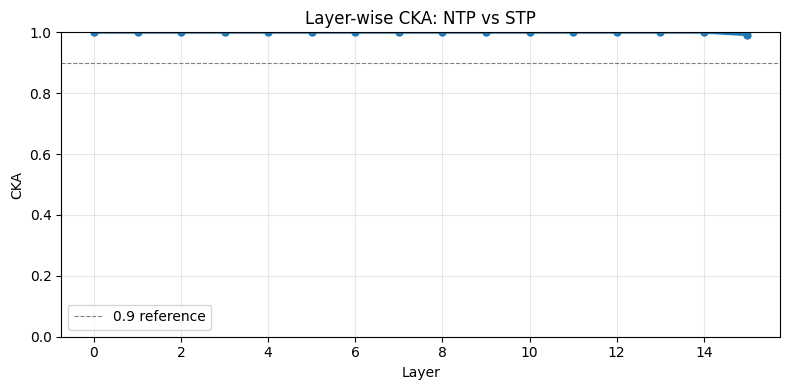

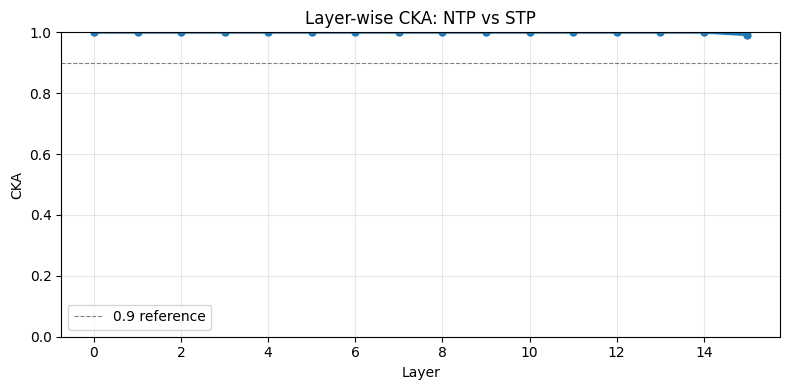

In [6]:
from datasets import load_dataset

# Load diverse text — same inputs run through both models
_ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
cka_texts = [ex["text"][:1024] for ex, _ in zip(_ds, range(64))]

cka_values = layerwise_cka(
    MODELS["NTP"],
    MODELS["STP"],
    cka_texts,
    n_layers=16,
    batch_size=8,
    seq_len=128,
)

plot_cka_profile(cka_values, save_path="analysis/cka_profile.png")

Interpretation: the geometry is mostly the same, whch is unsurprising because the only thing that changed was the lora adapter.

## LoRA Weight Diff Analysis

Since both models are merged LoRA checkpoints, we can directly compare weight matrices.
The heatmap shows relative Frobenius norm of the change per layer and module type.
The SVD plot verifies the low-rank structure — energy should concentrate in the top 16 singular values.

Loading models for weight diff analysis...


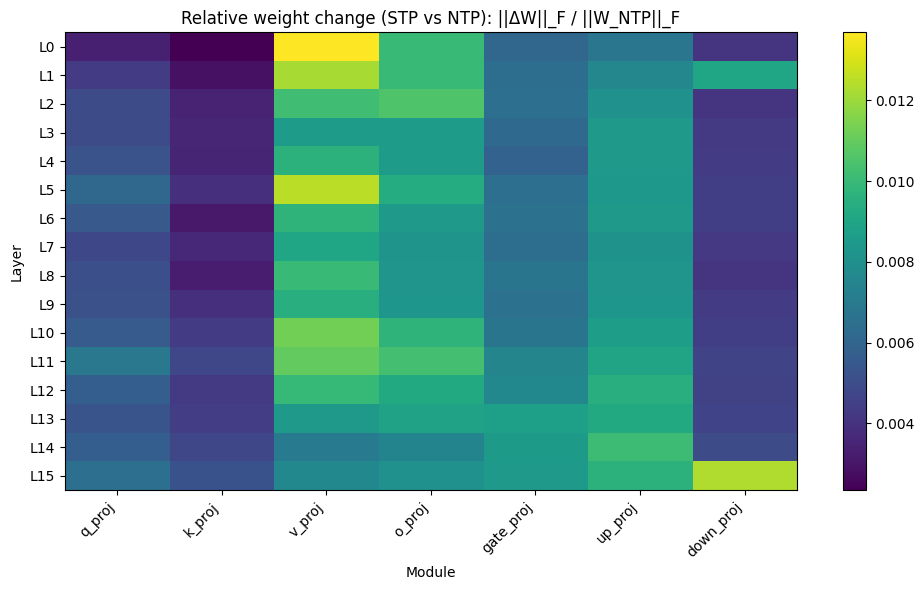

Top 10 changed modules:
  Layer  0 v_proj      : 0.0137
  Layer  5 v_proj      : 0.0125
  Layer 15 down_proj   : 0.0124
  Layer  1 v_proj      : 0.0122
  Layer 10 v_proj      : 0.0113
  Layer 11 v_proj      : 0.0110
  Layer  2 o_proj      : 0.0105
  Layer 11 o_proj      : 0.0103
  Layer  2 v_proj      : 0.0102
  Layer 14 up_proj     : 0.0101


In [4]:
import numpy as np

norms, mod_types = lora_weight_diffs(MODELS["NTP"], MODELS["STP"])
plot_weight_diff_heatmap(norms, mod_types, save_path="analysis/lora_diff_heatmap.png")

# Print top changed modules
flat_idx = np.argsort(norms.ravel())[::-1][:10]
print("Top 10 changed modules:")
for idx in flat_idx:
    layer, mod = divmod(idx, len(mod_types))
    print(f"  Layer {layer:2d} {mod_types[mod]:12s}: {norms[layer, mod]:.4f}")

Inspecting: layer 0, v_proj


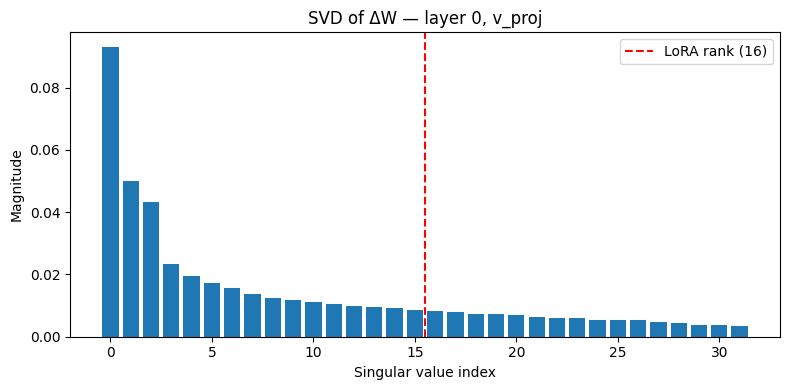

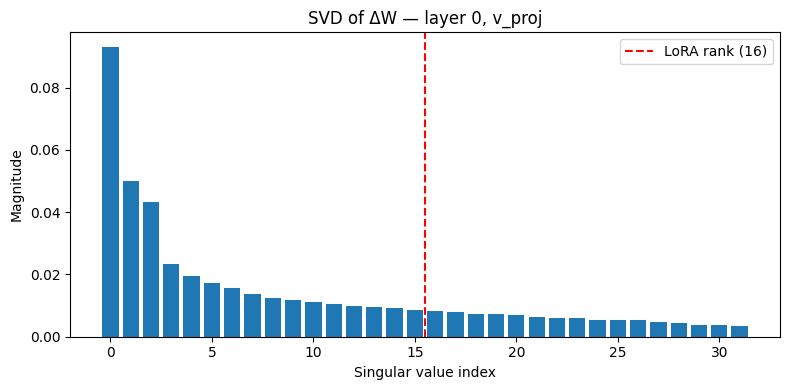

In [5]:
# SVD of the most-changed module to verify low-rank structure
top_flat = np.argmax(norms)
top_layer, top_mod_idx = divmod(int(top_flat), len(mod_types))
top_mod = mod_types[top_mod_idx]
print(f"Inspecting: layer {top_layer}, {top_mod}")

sv = lora_diff_rank_structure(MODELS["NTP"], MODELS["STP"], top_layer, top_mod)
plot_singular_values(sv, top_layer, top_mod, lora_rank=16, save_path="analysis/lora_diff_svd.png")

Interpretation: we can tell that most of the lora change occura on the v_proj matrix. Also, it appears the changes are very low rank, lower than what lora was even trained on.